In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from common.utils import pipeline
from common.ETL import save_mart

### Общие ETL шаги:
1. Выгрузка сырых данных из БД
2. Сохранение сырых данных в S3 (Если есть столбец с датами, то по нему идет разбивка)
3. Выгрузка сырых данных из S3
4. Предоработка null значений (Для чисел берется среднее, для остальных фраза "Нет данных")
5. Предобработка выбросов

In [2]:
tables = {
    "wells": {
        "date_column": "start_date"
    },

    "production": {
        "date_column": "date"
    }
}

results = []

for key in tables.keys():
    results.append(pipeline(table_name=key, date_column=tables[key]["date_column"]))

df_wells = results[0].copy()
df_production = results[1].copy()

### Общая добыча по дням

In [3]:
mart_daily_prod = (
    df_production
    .groupby("date", as_index=False)
    .agg(
        total_oil_ton=("oil_ton", "sum"),
        total_gas_m3=("gas_m3", "sum"),
        total_water_m3=("water_m3", "sum"),
        total_energy_kwh=("energy_kwh", "sum"),
        avg_pressure=("pressure", "mean"),
        avg_temperature=("temperature", "mean"),
        total_downtime_hours=("downtime_hours", "sum")
    )
)

mart_daily_prod.head()

,date,total_oil_ton,total_gas_m3,total_water_m3,total_energy_kwh,avg_pressure,avg_temperature,total_downtime_hours
0,2025-10-01,595.7,157050.0,509.6,21450.0,118.200000,86.366667,1.7
1,2025-10-02,596.6,157190.0,509.7,21485.0,118.366667,86.266667,1.8
2,2025-10-03,597.1,157170.0,509.8,21470.0,118.233333,86.733333,2.0
3,2025-10-04,599.9,157510.0,507.1,21545.0,118.800000,86.133333,1.2
4,2025-10-05,599.6,157480.0,508.9,21530.0,118.633333,86.400000,1.4


### KPI по скважинам

In [4]:
mart_well_kpi = (
    df_production
    .groupby("well_id", as_index=False)
    .agg(
        total_oil_ton=("oil_ton", "sum"),
        avg_oil_ton=("oil_ton", "mean"),
        avg_pressure=("pressure", "mean"),
        avg_temperature=("temperature", "mean"),
        total_energy_kwh=("energy_kwh", "sum"),
        total_downtime_hours=("downtime_hours", "sum"),
        days_count=("date", "nunique")
    )
)

mart_well_kpi["downtime_ratio"] = mart_well_kpi["total_downtime_hours"] / (mart_well_kpi["days_count"] * 24)

mart_well_kpi["downtime_percent"] = mart_well_kpi["downtime_ratio"] * 100

mart_well_kpi = mart_well_kpi.merge(
    df_wells,
    on="well_id",
    how="left"
)

### Средний дебит по скважинам

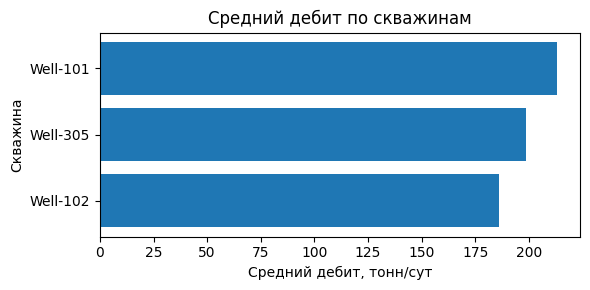

In [5]:
plot_df = mart_well_kpi.sort_values("avg_oil_ton")

label_col = "name" if "name" in plot_df.columns else "well_id"

plt.figure(figsize=(6, 3))
plt.barh(plot_df[label_col].astype(str), plot_df["avg_oil_ton"])
plt.title("Средний дебит по скважинам")
plt.xlabel("Средний дебит, тонн/сут")
plt.ylabel("Скважина")
plt.tight_layout()
plt.show()

### Процент простоя

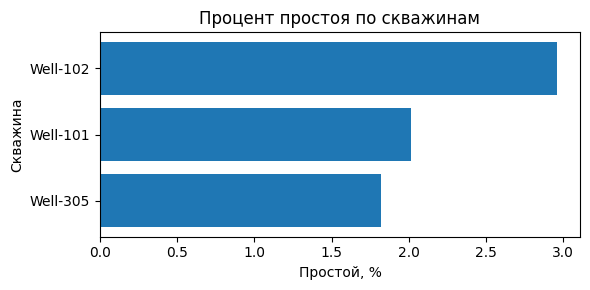

In [8]:
plot_df = mart_well_kpi.sort_values("downtime_percent")

label_col = "name" if "name" in plot_df.columns else "well_id"

plt.figure(figsize=(6, 3))
plt.barh(plot_df[label_col].astype(str), plot_df["downtime_percent"])
plt.title("Процент простоя по скважинам")
plt.xlabel("Простой, %")
plt.ylabel("Скважина")
plt.tight_layout()
plt.show()

### Витрина для Heatmap (давление vs дебит)

In [10]:
mart_pressure_temperature = df_production.copy()

mart_pressure_temperature["pressure_bin"] = pd.cut(
    mart_pressure_temperature["pressure"],
    bins=5
)

mart_pressure_temperature["temperature_bin"] = pd.cut(
    mart_pressure_temperature["temperature"],
    bins=5
)

mart_pressure_temperature = (
    mart_pressure_temperature
    .groupby(["pressure_bin", "temperature_bin"], as_index=False, observed=True)
    .agg(
        avg_oil_ton=("oil_ton", "mean"),
        records_count=("oil_ton", "count")
    )
)

mart_pressure_temperature["pressure_bin"] = mart_pressure_temperature["pressure_bin"].astype(str)
mart_pressure_temperature["temperature_bin"] = mart_pressure_temperature["temperature_bin"].astype(str)

mart_pressure_temperature.head()

,pressure_bin,temperature_bin,avg_oil_ton,records_count
0,"(114.793, 116.14]","(84.195, 85.18]",185.872414,29
1,"(117.48, 118.82]","(86.16, 87.14]",197.200000,1
2,"(118.82, 120.16]","(86.16, 87.14]",198.472414,29
3,"(118.82, 120.16]","(88.12, 89.1]",211.887500,8
4,"(120.16, 121.5]","(87.14, 88.12]",214.000000,15


### Влияние давления/температуры на дебит

In [7]:
pressure_corr = df_production["oil_ton"].corr(df_production["pressure"])
temperature_corr = df_production["oil_ton"].corr(df_production["temperature"])

print(f"Корреляция добычи и давления: {pressure_corr:.2f}")
print(f"Корреляция добычи и температуры: {temperature_corr:.2f}")

Корреляция добычи и давления: 0.93
Корреляция добычи и температуры: 0.96


### Сохранение витрин в БД

In [11]:
save_mart(mart_daily_prod, "mart_daily_production")
save_mart(mart_well_kpi, "mart_well_kpi")
save_mart(mart_pressure_temperature, "mart_pressure_temperature")